In [11]:
from dataset import FLAIRDataset
from torch.utils.data import DataLoader

dataset = FLAIRDataset("../datasets/FLAIR", "validation")
loader_valid = DataLoader(dataset, batch_size=10)
images, masks = next(iter(loader_valid))

print(images.shape)
print(masks.shape)
print()

idx = 0

print(images[idx].min())
print(images[idx].max())
print(images[idx].mean())
print()

print(masks[idx].min())
print(masks[idx].max())
print(masks[idx].mean())

torch.Size([10, 3, 256, 256])
torch.Size([10, 1, 256, 256])

tensor(0.)
tensor(0.8706)
tensor(0.0705)

tensor(0.)
tensor(0.)
tensor(0.)


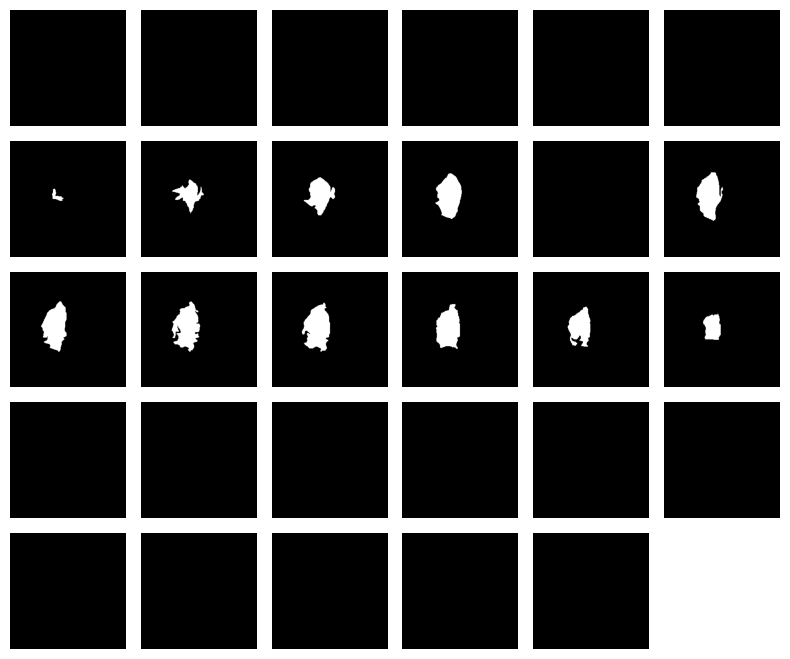

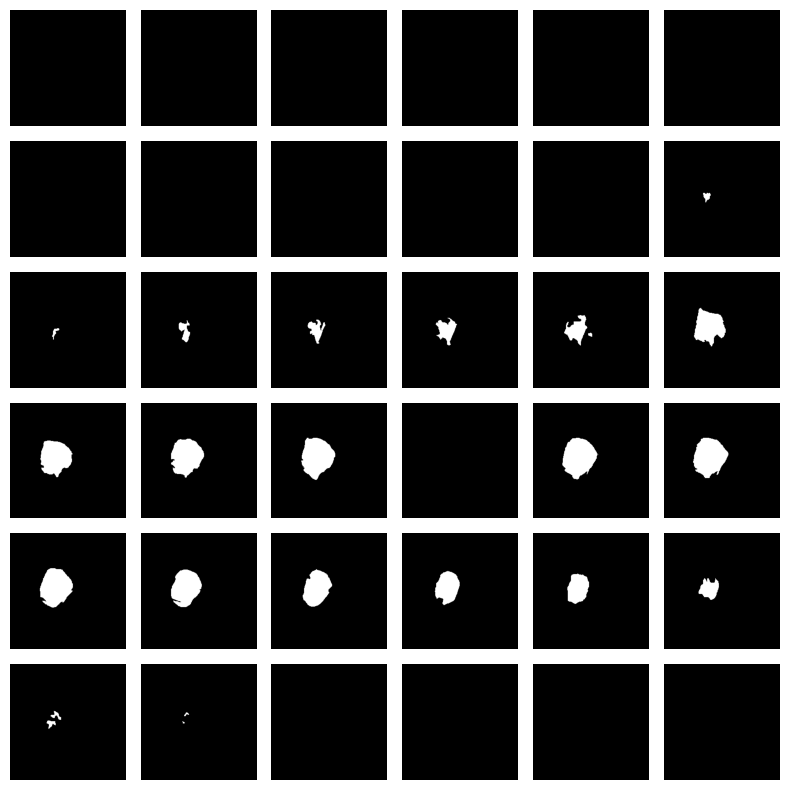

In [9]:
import matplotlib.pyplot as plt

for i, (v, m) in enumerate(dataset.volumes):
    if i == 2: 
        break 

    fig = plt.figure(figsize=(8, 8))
    index = 1
    rows = 6
    cols = 6

    for images, masks in zip(v, m):
        if index > (rows * cols):
            break

        fig.add_subplot(rows, cols, index)
        plt.subplots_adjust(wspace=None, hspace=None)
        plt.axis('off')
        plt.imshow(masks, cmap='gray')
        index += 1

    plt.tight_layout()
    plt.show()

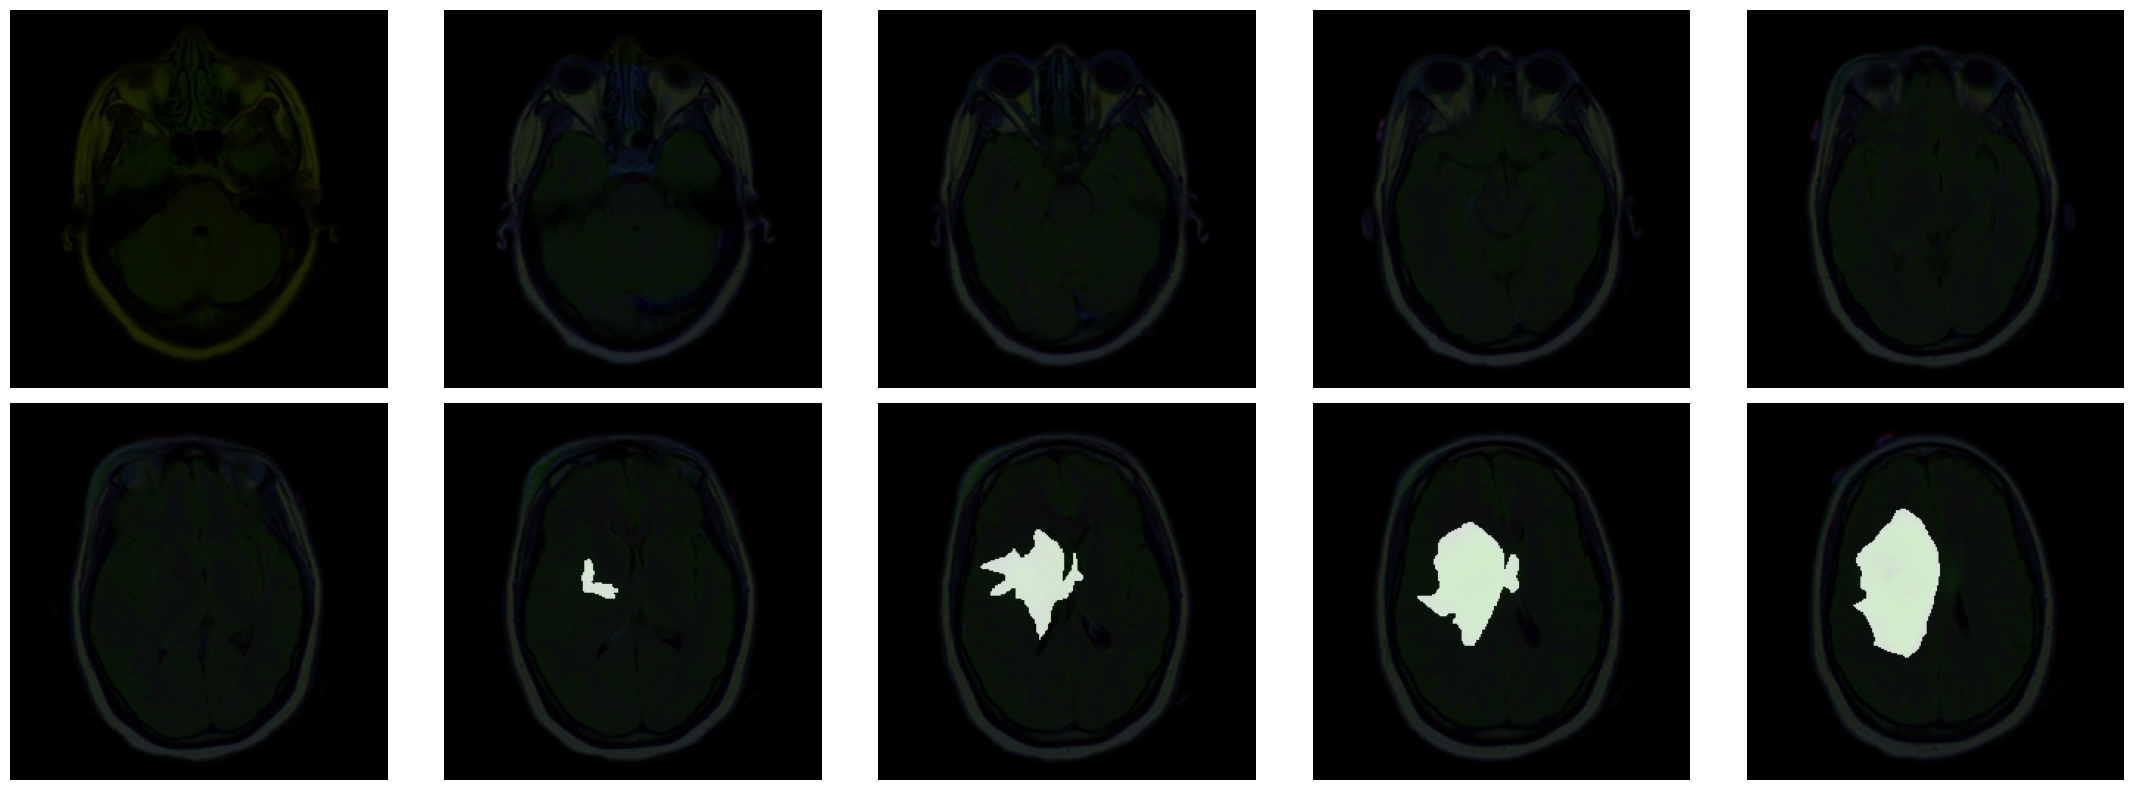

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def sample_images(images, masks, subplots=(2,5), figsize=(22,8), save=False):
    plt.figure(figsize=figsize)

    for i, image in enumerate(images):
        plt.subplot(subplots[0], subplots[1], i+1)
        plt.imshow(image.permute(1, 2, 0))
        plt.imshow(masks[i].permute(1, 2, 0), alpha=0.8, cmap='gray')
        plt.subplots_adjust(wspace=None, hspace=None)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

sample_images(images, masks)